In [10]:
#Python v3.11.8
#Import necessary packages

import os
import sys

import pandas as pd
import numpy as np

sys.path.append('functions')

from greatbrowser import great_analysis

from gene_analysis_functions import get_cistrome, get_pos, insig_nan
from pseudoinverse_functions import pinv_dropmin, quality_filter, trait_cluster

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
'''
Establich cwd, get relevant data, and perform basic formatting
'''

#set directory, import data, drop undefined
os.chdir('/Users/samanderson/Desktop/pellegrini_lab_research/raw_data')
data = pd.read_excel('methylation_phenotype_encoded.xlsx', index_col=0) #mm39
data = data.dropna()

#referring to the point in the data where methylation and phenotype data diverge
sep=55

#seperate trait and methylation data
trait_data = data[:sep]
meth_data = data[sep:]

print(f'{trait_data.shape[0]} traits')

55 traits


In [12]:
#filter trait data to minimize colinearity
filter = 0.5
f_trait_data = quality_filter(trait_data, filter)

print(f'{f_trait_data.shape[0]} traits')

12 traits


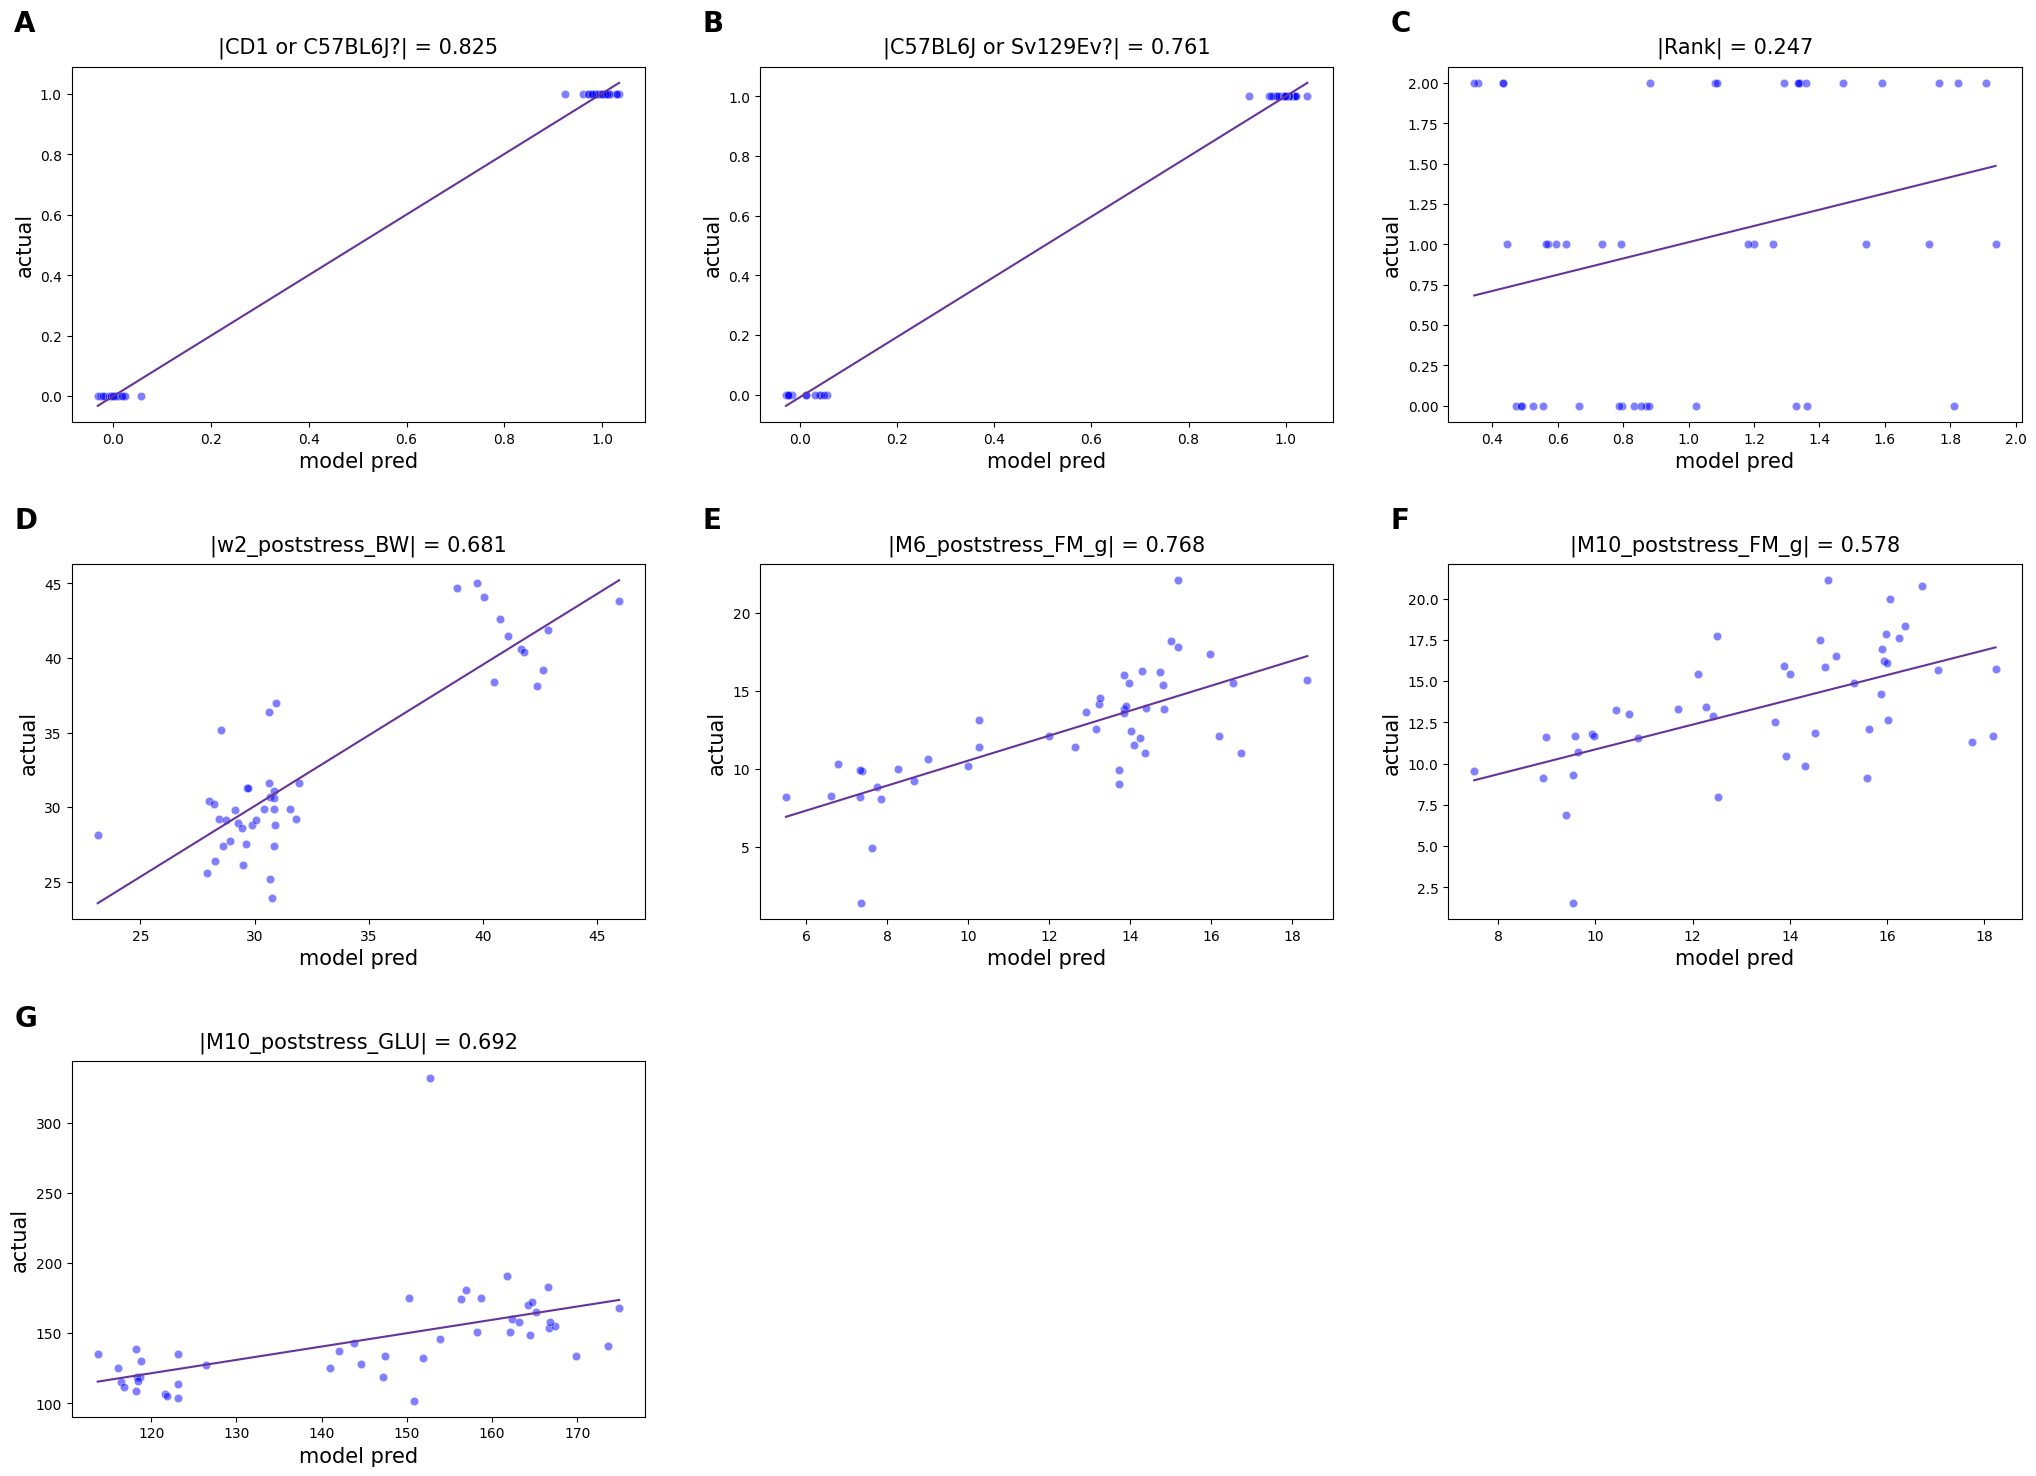

In [13]:
#generate pseudoinversion plots
thresh = 0.5
meth_filter_thresh = 0.5
pinv_dropmin(f_trait_data, meth_data, thresh, 
             find_meth=False, to_filter_meth=True, 
             meth_filter_thresh=meth_filter_thresh);

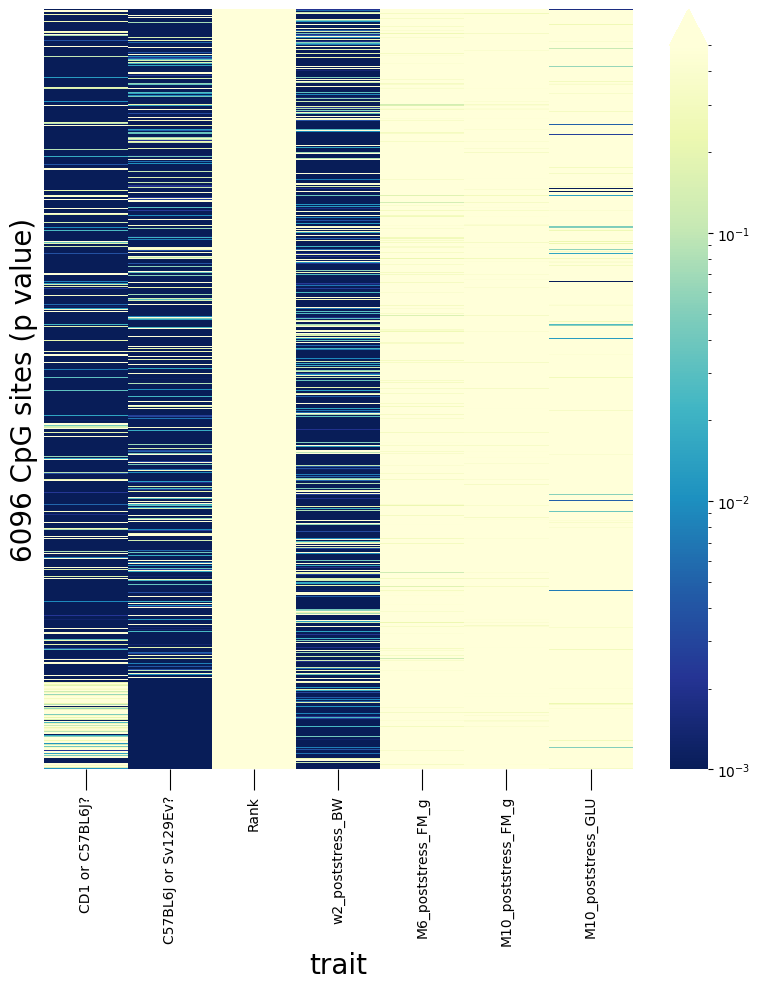

In [14]:
#generate heatmap of probe/trait multivar association p values
thresh = 0.5
meth_filter_thresh = 0.5
is_filtered = True
trait_vals, trait_pvals, trait_coef = pinv_dropmin(f_trait_data, meth_data, thresh, 
                                                   find_meth=True, plot_results=True, 
                                                   to_filter_meth=is_filtered, meth_filter_thresh=meth_filter_thresh);

In [15]:
#identify most significant probes
mm39_data = pd.read_excel('mm39_formatted_manifest.xlsx', index_col=0)
probe_df = get_pos(trait_vals, mm39_data);

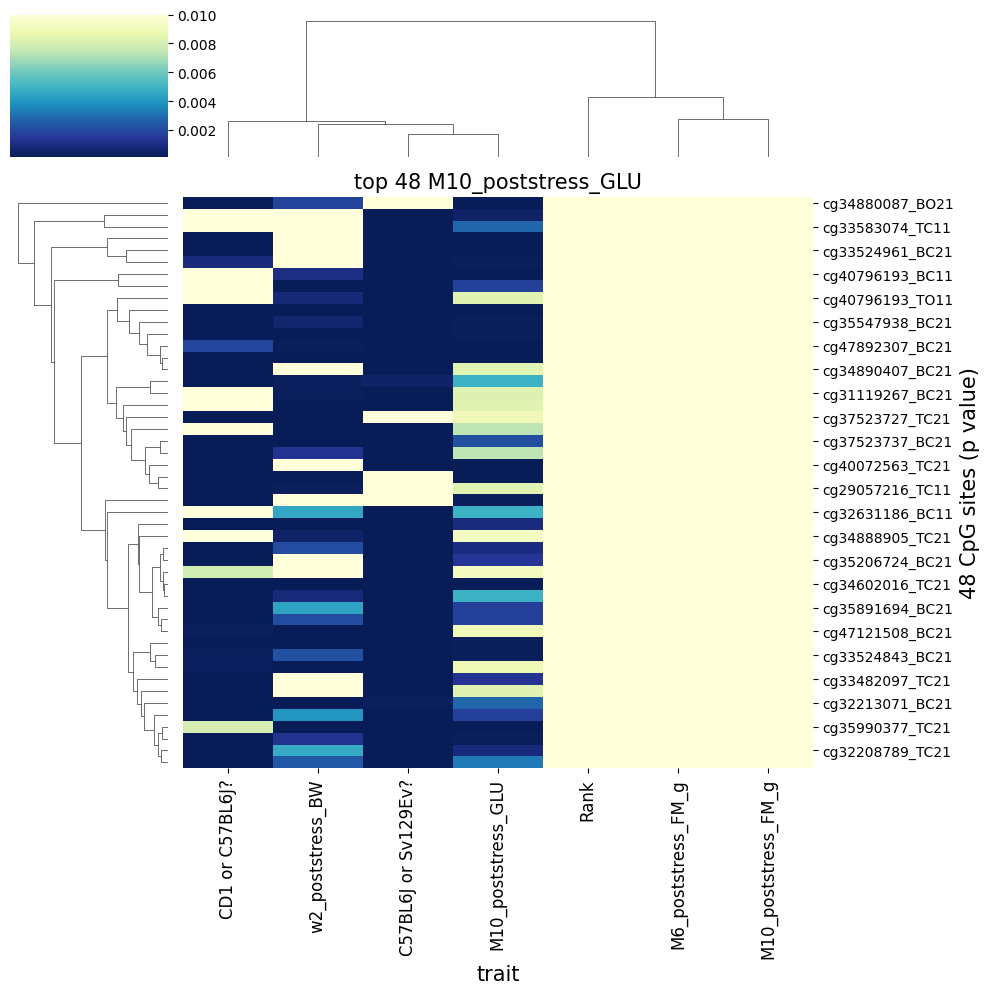

In [16]:
#generate a clustermap of significant probes for selected trait
sig_df = insig_nan(probe_df)
trait = 'M10_poststress_GLU_pval'

temp = sig_df[trait].values
temp = temp[~np.isnan(temp)]
n_probes = len(temp)

trait_cluster(trait_pvals, trait[:-5], n_probes);

In [17]:
#find gene associations of probes via GREAT

temp = probe_df.reset_index()
temp = great_analysis(temp, get='genes', df_chr ='chr_mm10', df_start='pos_mm10', df_end='end_mm10', df_index='index')

temp = temp.set_index('index')
trait_vals['associated_genes'] = temp['associated_genes']

'''
if is_filtered:
    trait_vals.to_excel('pseudoinverse_probes_filtered.xlsx')
else:
    trait_vals.to_excel('pseudoinverse_probes_unfiltered.xlsx')
'''

trait_vals

,CD1 or C57BL6J?_pval,CD1 or C57BL6J?_coef,C57BL6J or Sv129Ev?_pval,C57BL6J or Sv129Ev?_coef,Rank_pval,Rank_coef,w2_poststress_BW_pval,w2_poststress_BW_coef,M6_poststress_FM_g_pval,M6_poststress_FM_g_coef,...,M10_poststress_FM_g_coef,M10_poststress_GLU_pval,M10_poststress_GLU_coef,chr_mm39,pos_mm39,end_mm39,chr_mm10,pos_mm10,end_mm10,associated_genes
index,,,,,,,,,,,,,,,,,,,,,
cg20012035_TC21,1.434921e-11,0.154960,6.346386e-21,0.213053,0.996259,0.001885,1.593360e-09,0.006098,0.717930,-0.003198,...,0.002541,0.951888,-0.000083,chr12,111505954,111505956,chr12,111539520.0,111539522.0,"Mark3 (-35,006), Eif5 (+1,505)"
cg28108956_TC21,5.957986e-13,0.157585,1.204890e-20,0.188613,0.996259,-0.002010,1.239570e-13,0.008342,0.795219,-0.002372,...,0.002825,0.977017,0.000055,chr6,40524504,40524506,chr6,40547570.0,40547572.0,"Prss37 (-28,063), Olfr461 (+7,479)"
cg28108999_TC21,9.793948e-12,0.144500,5.346638e-09,0.076946,0.996259,0.003305,9.563998e-04,0.002528,0.920692,-0.001114,...,0.000712,0.012998,-0.000601,chr10,3207379,3207381,chr10,3257379.0,3257381.0,"H60c (+10,391)"
cg28113426_BC11,1.351915e-36,0.649436,5.549067e-01,-0.005058,0.941286,-0.007093,1.951987e-02,0.001366,0.976131,-0.000299,...,0.000020,0.930512,-0.000081,chr10,3802852,3802854,chr10,3852852.0,3852854.0,"Mthfd1l (-120,278), Plekhg1 (+112,489)"
cg28116521_BC11,3.606046e-16,0.584242,6.352707e-08,0.194316,0.996259,0.007607,2.091544e-03,0.006583,0.942455,-0.002473,...,0.002078,0.001721,-0.002043,chr10,4080228,4080230,chr10,4130228.0,4130230.0,"Akap12 (-136,151), Mthfd1l (+157,098)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg48343432_BC11,1.633814e-08,0.556289,8.541587e-03,0.151189,0.996259,0.008518,8.766932e-01,0.000624,0.995976,-0.000172,...,0.000708,0.923368,0.000577,chrY,90751530,90751532,chrY,90740261.0,90740263.0,"Gm21996 (-994,730), Erdr1 (-44,476)"
cg48343860_TC21,7.196697e-15,0.542339,5.192259e-09,0.223095,0.996259,0.002756,5.531882e-01,-0.001277,0.619510,-0.010600,...,0.006874,0.758241,0.000631,chrY,90771588,90771590,chrY,90760319.0,90760321.0,"Erdr1 (-24,418)"
cg48344016_TC11,1.875534e-12,0.323885,4.867806e-08,0.146711,0.996259,-0.011197,8.941446e-08,0.009813,0.993970,-0.000170,...,0.002826,0.947714,0.000177,chrY,90813306,90813308,chrY,90802037.0,90802039.0,"Erdr1 (+17,300)"


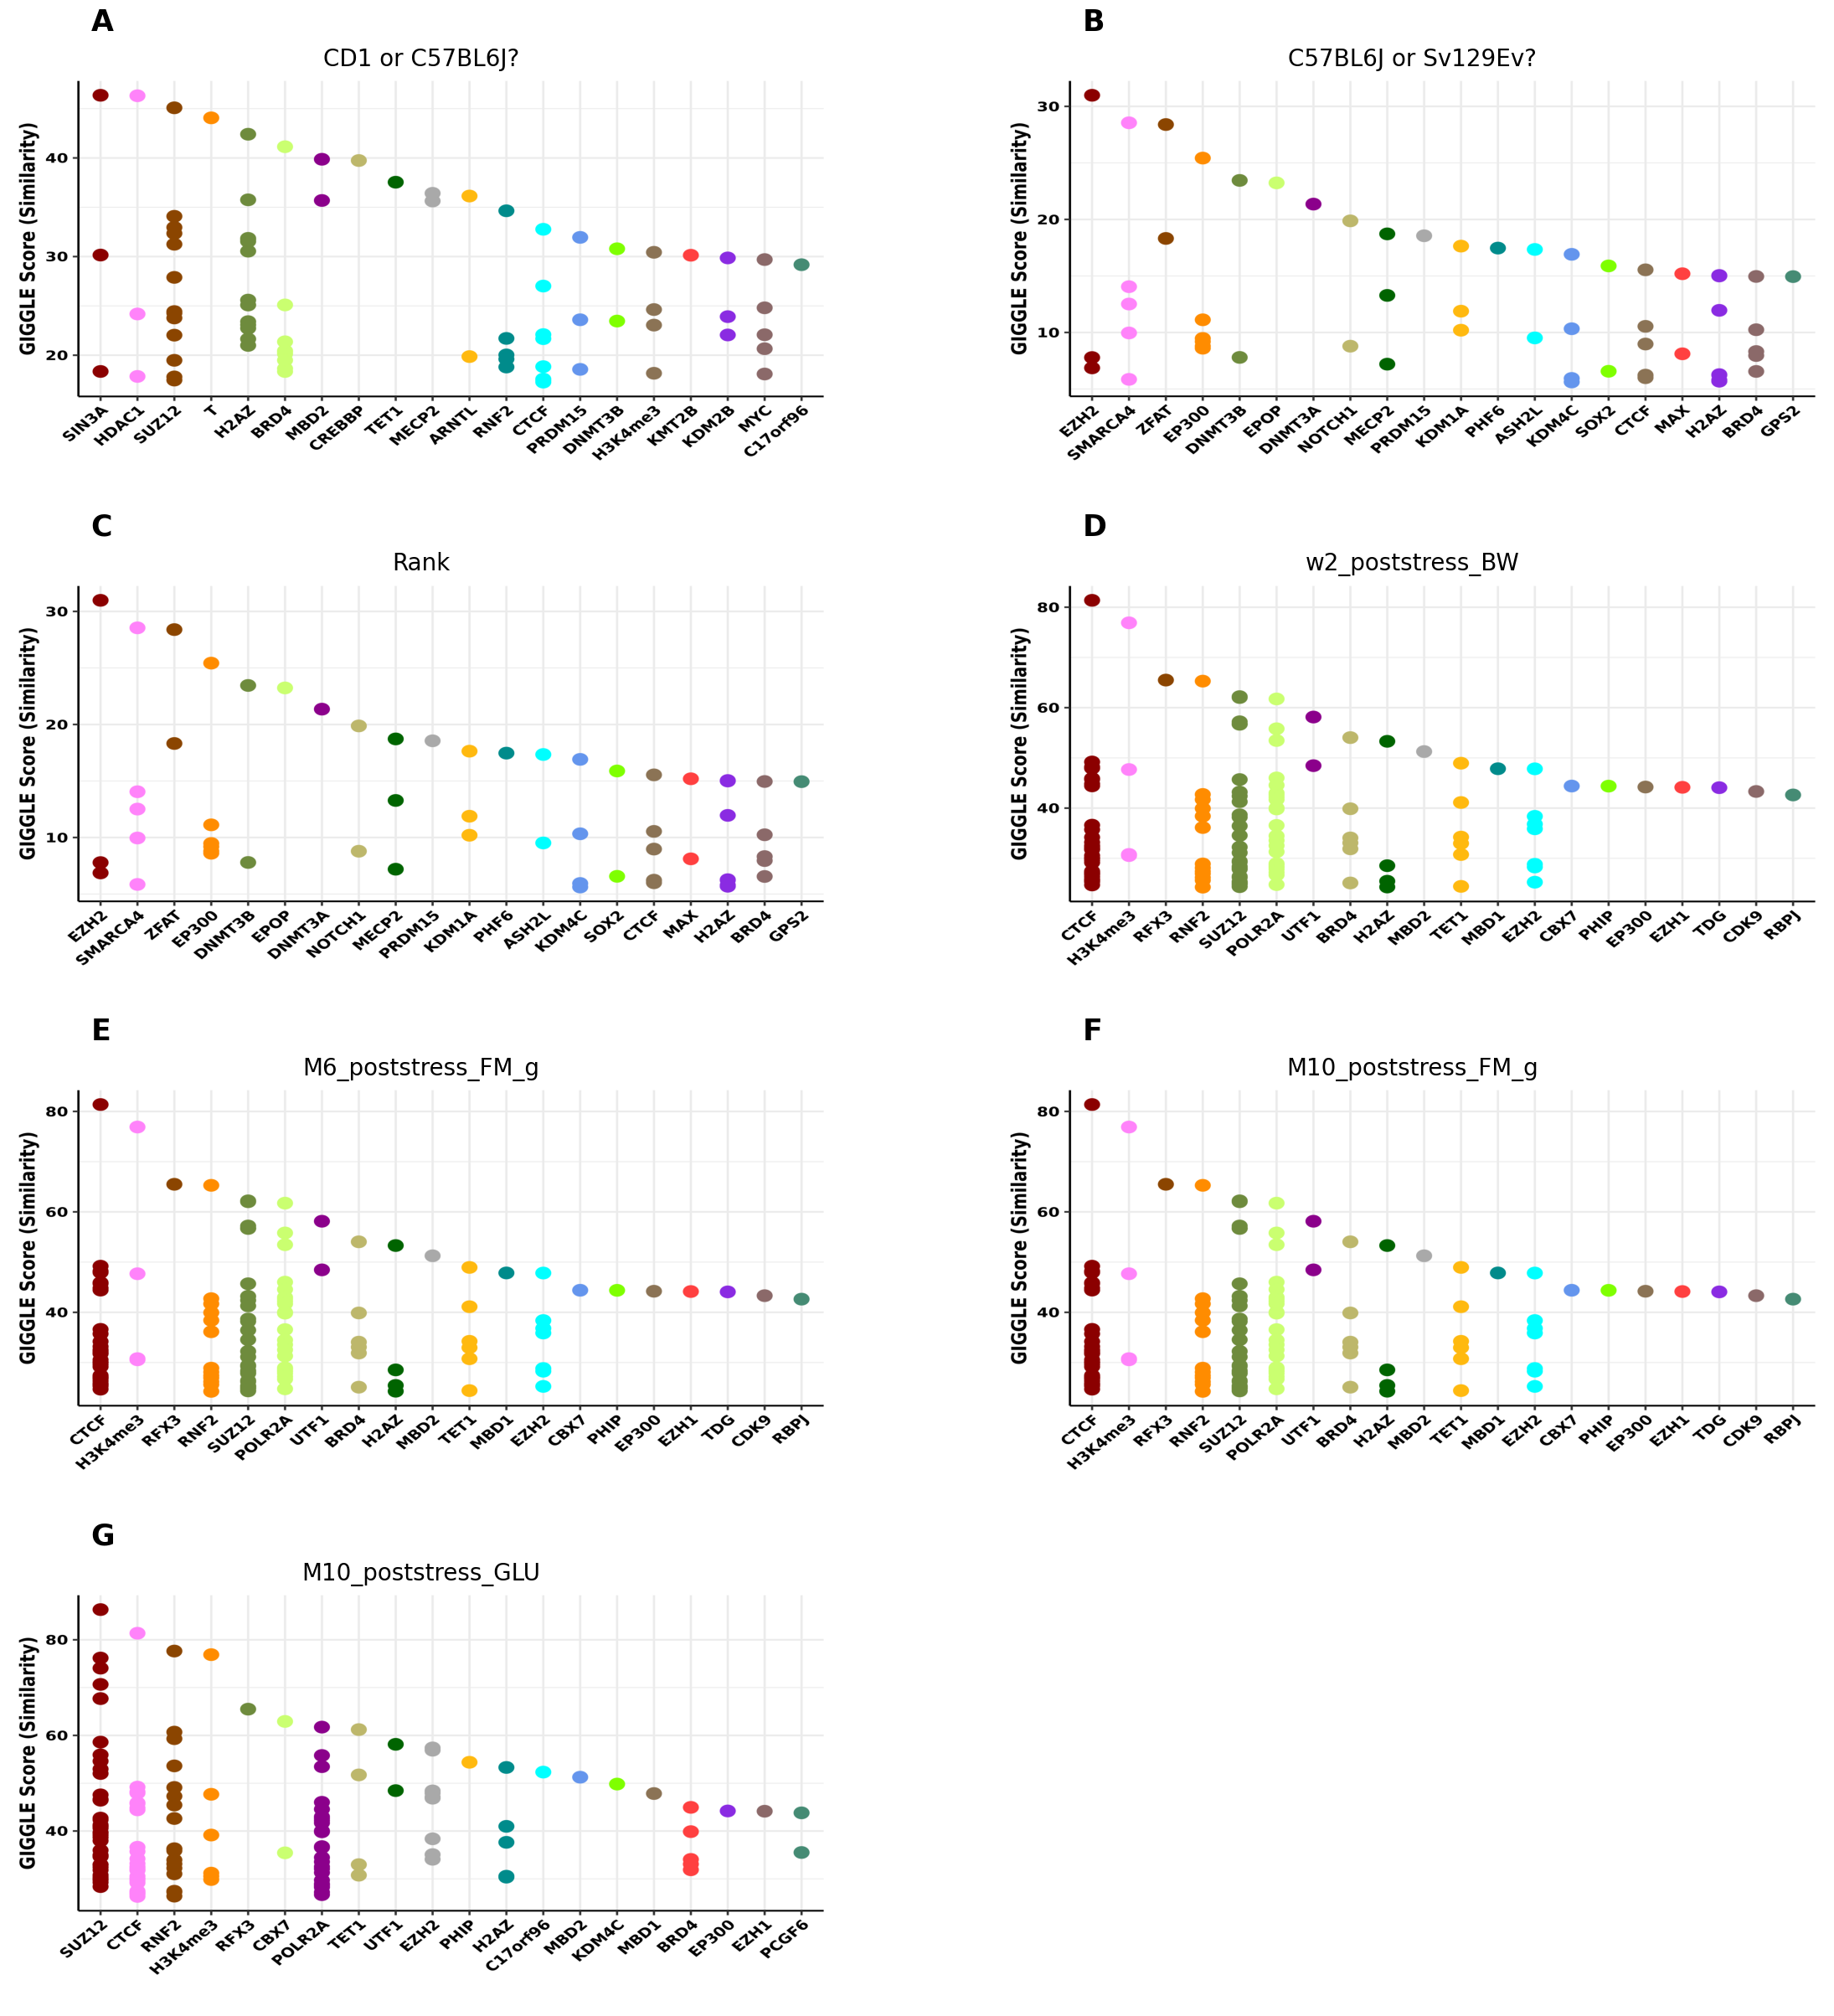

In [18]:
%matplotlib inline

#drop insignificant values
cistrome_df = insig_nan(trait_vals)

#this is trial and error, unfortunately 
fig_w = 2800
fig_h = 3000

#generate cistrome plots by trait for significant probes
get_cistrome(cistrome_df, fig_w, fig_h)